
=== Gemma vs Human ===

Random Forest Accuracy for Gemma: 0.72
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       248
           1       0.71      0.76      0.74       250

    accuracy                           0.72       498
   macro avg       0.73      0.72      0.72       498
weighted avg       0.73      0.72      0.72       498

Confusion Matrix:
 [[171  77]
 [ 60 190]]

Logistic Regression Accuracy for Gemma: 0.64
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       248
           1       0.62      0.72      0.67       250

    accuracy                           0.64       498
   macro avg       0.65      0.64      0.64       498
weighted avg       0.65      0.64      0.64       498

Confusion Matrix:
 [[139 109]
 [ 69 181]]

SVM Accuracy for Gemma: 0.67
              precision    recall  f1-score   support

           0       0.79      0.46      0.58       248
           1 

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:13:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Gradient Boosting Accuracy for Gemma: 0.70
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       248
           1       0.69      0.72      0.71       250

    accuracy                           0.70       498
   macro avg       0.70      0.70      0.70       498
weighted avg       0.70      0.70      0.70       498

Confusion Matrix:
 [[167  81]
 [ 69 181]]

=== Mistral vs Human ===

Random Forest Accuracy for Mistral: 0.69
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       248
           1       0.69      0.69      0.69       250

    accuracy                           0.69       498
   macro avg       0.69      0.69      0.69       498
weighted avg       0.69      0.69      0.69       498

Confusion Matrix:
 [[170  78]
 [ 77 173]]

Logistic Regression Accuracy for Mistral: 0.65
              precision    recall  f1-score   support

           0       0.67      0.58      0.63    

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest Accuracy for LLaMa 3.3 70B: 0.83
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       248
           1       0.82      0.85      0.83       250

    accuracy                           0.83       498
   macro avg       0.83      0.83      0.83       498
weighted avg       0.83      0.83      0.83       498

Confusion Matrix:
 [[200  48]
 [ 37 213]]

Logistic Regression Accuracy for LLaMa 3.3 70B: 0.74
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       248
           1       0.72      0.78      0.75       250

    accuracy                           0.74       498
   macro avg       0.74      0.74      0.74       498
weighted avg       0.74      0.74      0.74       498

Confusion Matrix:
 [[171  77]
 [ 54 196]]

SVM Accuracy for LLaMa 3.3 70B: 0.77
              precision    recall  f1-score   support

           0       0.80      0.71      0.75       248
           1 

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:13:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest Accuracy for GPT 4.1: 0.81
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       248
           1       0.83      0.79      0.81       250

    accuracy                           0.81       498
   macro avg       0.81      0.81      0.81       498
weighted avg       0.81      0.81      0.81       498

Confusion Matrix:
 [[207  41]
 [ 52 198]]

Logistic Regression Accuracy for GPT 4.1: 0.78
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       248
           1       0.79      0.77      0.78       250

    accuracy                           0.78       498
   macro avg       0.78      0.78      0.78       498
weighted avg       0.78      0.78      0.78       498

Confusion Matrix:
 [[196  52]
 [ 57 193]]

SVM Accuracy for GPT 4.1: 0.79
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       248
           1       0.77      0.

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:13:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


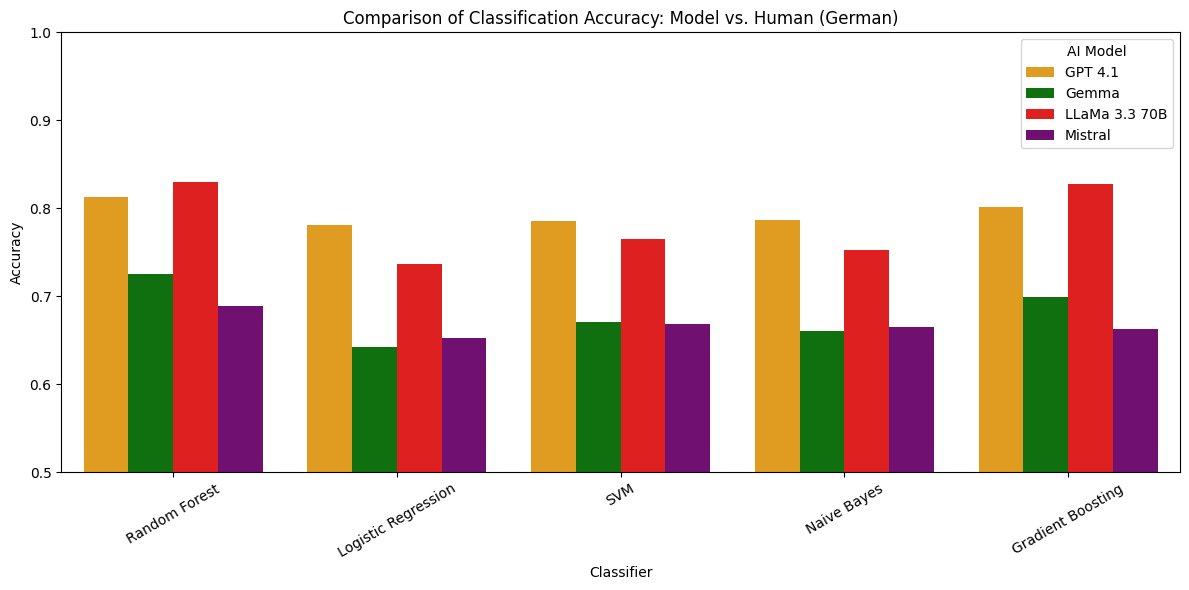

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# Load AI parquet
ai_df = pd.read_parquet("combined_results_Ger.parquet").reset_index()

if "label" not in ai_df.columns:
    raise ValueError("AI Parquet file must contain 'label' column")

# Extract model name
def extract_model_name(exp_name):
    if "Gemma" in exp_name:
        return "Gemma"
    elif "Mistral" in exp_name:
        return "Mistral"
    elif "Llama" in exp_name:
        return "LLaMa 3.3 70B"
    elif "GPT" in exp_name:
        return "GPT 4.1"
    else:
        return "Other"

ai_df["model"] = ai_df["experiment"].apply(extract_model_name)

# --- Load both human JSON files ---
def load_human_json(paths):
    rows = []
    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for item in data:
            rows.append({
                "document_id": item["filename"].strip(),
                "label": item["prediction"]["label"]
            })
    return pd.DataFrame(rows)

human_df = load_human_json([
    "gutenberg_results.json",
    "gutenberg_results_missing_files_de.json"
])

classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

ai_models = ["Gemma", "Mistral", "LLaMa 3.3 70B", "GPT 4.1"]
results = []

for model in ai_models:
    print(f"\n=== {model} vs Human ===")

    # AI subset for this model
    ai_subset = ai_df[ai_df["model"] == model]

    # AI per-document distribution
    ai_features = ai_subset.pivot_table(
        index="document_id",
        columns="label",
        aggfunc="size",
        fill_value=0
    )
    ai_features = ai_features.div(ai_features.sum(axis=1), axis=0)
    ai_features["target"] = 1

    # Human per-document distribution
    human_features = human_df.pivot_table(
        index="document_id",
        columns="label",
        aggfunc="size",
        fill_value=0
    )
    human_features = human_features.div(human_features.sum(axis=1), axis=0)
    human_features["target"] = 0

    # Combine
    combined = pd.concat([ai_features, human_features], axis=0)

    # Train/test split
    X = combined.drop(columns=["target"])
    y = combined["target"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=42, test_size=0.25
    )

    # Train all classifiers
    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        print(f"\n{clf_name} Accuracy for {model}: {acc:.2f}")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

        results.append({
            "Model": model,
            "Classifier": clf_name,
            "Accuracy": acc
        })

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))

# Fixed order of models
model_order = ["GPT 4.1", "Gemma", "LLaMa 3.3 70B", "Mistral"]
model_colors = {
    "GPT 4.1": "orange",
    "Gemma": "green",
    "LLaMa 3.3 70B": "red",
    "Mistral": "purple"
}

sns.barplot(
    data=results_df,
    x="Classifier",
    y="Accuracy",
    hue="Model",
    hue_order=model_order,
    palette=model_colors
)

plt.title("Comparison of Classification Accuracy: Model vs. Human (German)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0.5, 1.0)
plt.legend(title="AI Model")
plt.tight_layout()
plt.show()
